In [2]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
random.seed(42) # define the seed (important to reproduce the results)

# Lê os dados do Google Drive
# Monta o Google Drive na pasta '/content/drive' deste ambiente do Colab.
# Depois deste comando, os arquivos do seu Drive ficam acessíveis normalmente,
# como se fossem arquivos locais dentro de '/content/drive/MyDrive/...'
# from google.colab import drive

# drive.mount('/content/drive/')
caminho_drive = r'C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\vertebralcolumn-3C.csv'
data = pd.read_csv(caminho_drive, header=0)

# Se for ler localmente, descomente.
#data = pd.read_csv('data/vertebralcolumn-3C.csv', header=(0))
#data = pd.read_csv('data/winequality-red.csv', header=(0))
#data = pd.read_csv('data/Vehicle.csv', header=(0))
#data = pd.read_csv('data/iris.csv', header=(0))

data = data.dropna(axis='rows') #remove NaN
# armazena os nomes das classes
classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)
# nomes dos atributos
features = data.columns
features = features[0:-1]

nrow, ncol = data.shape
print("Matriz de atributos: Número de linhas:", nrow, " colunas: ", ncol)
attributes = list(data.columns)
data.head(10)

Matriz de atributos: Número de linhas: 310  colunas:  7


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Hernia
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Hernia
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Hernia
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Hernia
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Hernia
5,40.250200,13.921907,25.124950,26.328293,130.327871,2.230652,Hernia
6,53.432928,15.864336,37.165934,37.568592,120.567523,5.988551,Hernia
7,45.366754,10.755611,29.038349,34.611142,117.270067,-10.675871,Hernia
8,43.790190,13.533753,42.690814,30.256437,125.002893,13.289018,Hernia
9,36.686353,5.010884,41.948751,31.675469,84.241415,0.664437,Hernia


In [3]:
import numpy as np

data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:, 0:-1].astype(float)

In [4]:
from sklearn.model_selection import train_test_split

p = 0.8
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=p, stratify = y)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


hiperparameters = {
    'n_neighbors': list(range(1, 11)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

model = KNeighborsClassifier()
best_model = GridSearchCV(model, hiperparameters, cv=10)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print('Melhores hiperparâmetros:', best_model.best_params_)
print('Acurácia média na validação cruzada (best_score_):', best_model.best_score_)
print('Acurácia sobre o conjunto de teste:', accuracy_score(y_pred, y_test))

Melhores hiperparâmetros: {'metric': 'euclidean', 'n_neighbors': 6, 'weights': 'distance'}
Acurácia média na validação cruzada (best_score_): 0.8305
Acurácia sobre o conjunto de teste: 0.7903225806451613


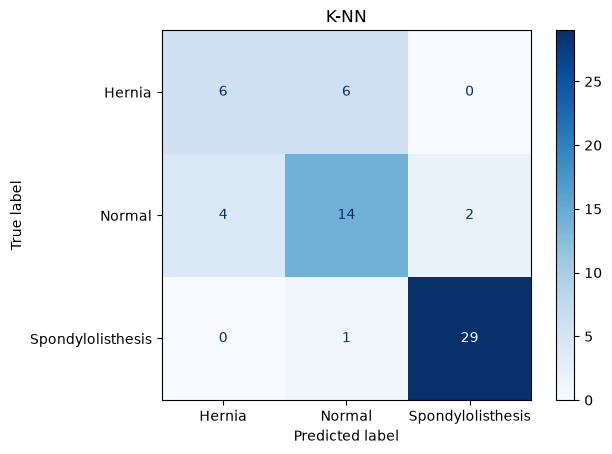

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matriz de confusão do K-NN
matriz = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap=plt.cm.Blues
)
plt.title('K-NN')
plt.show()

# Matriz de confusão da árvore de decisão
# The variable y_pred_tree is not defined in the current context.
# To plot the confusion matrix for a decision tree,
# please train a decision tree model and store its predictions in y_pred_tree.
# matriz = confusion_matrix(y_test, y_pred_tree)
# print(matriz)
# ConfusionMatrixDisplay.from_predictions(
#     y_test,
#     y_pred_tree,
#     cmap=plt.cm.Blues
# )
# plt.title('Árvore de decisão')
# plt.show()

In [9]:
from sklearn.metrics import f1_score

F1 = f1_score(y_test, y_pred, average='weighted')
print(F1)

0.7859448595928197
